# 🧠 Deep Learning - Partie 2: Perceptrons Multi-Couches (MLPs)

## 🎯 Objectifs
- Comprendre l'architecture des MLPs
- Implémenter la rétropropagation (backpropagation)
- Résoudre le problème XOR
- Visualiser l'apprentissage des représentations

---
*Session 05 - SupNum Nouakchott - Formation IA & Machine Learning*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, interactive
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("🚀 Prêt à explorer les MLPs!")

🚀 Prêt à explorer les MLPs!


## 🏗️ 1. Architecture d'un MLP

Un MLP (Multi-Layer Perceptron) est composé de :
- **Couche d'entrée** : reçoit les données
- **Couches cachées** : transforment les données
- **Couche de sortie** : produit la prédiction

### Avantages par rapport au perceptron simple :
- Peut résoudre des problèmes **non-linéairement séparables**
- Approximateur universel de fonctions
- Apprentissage de représentations complexes

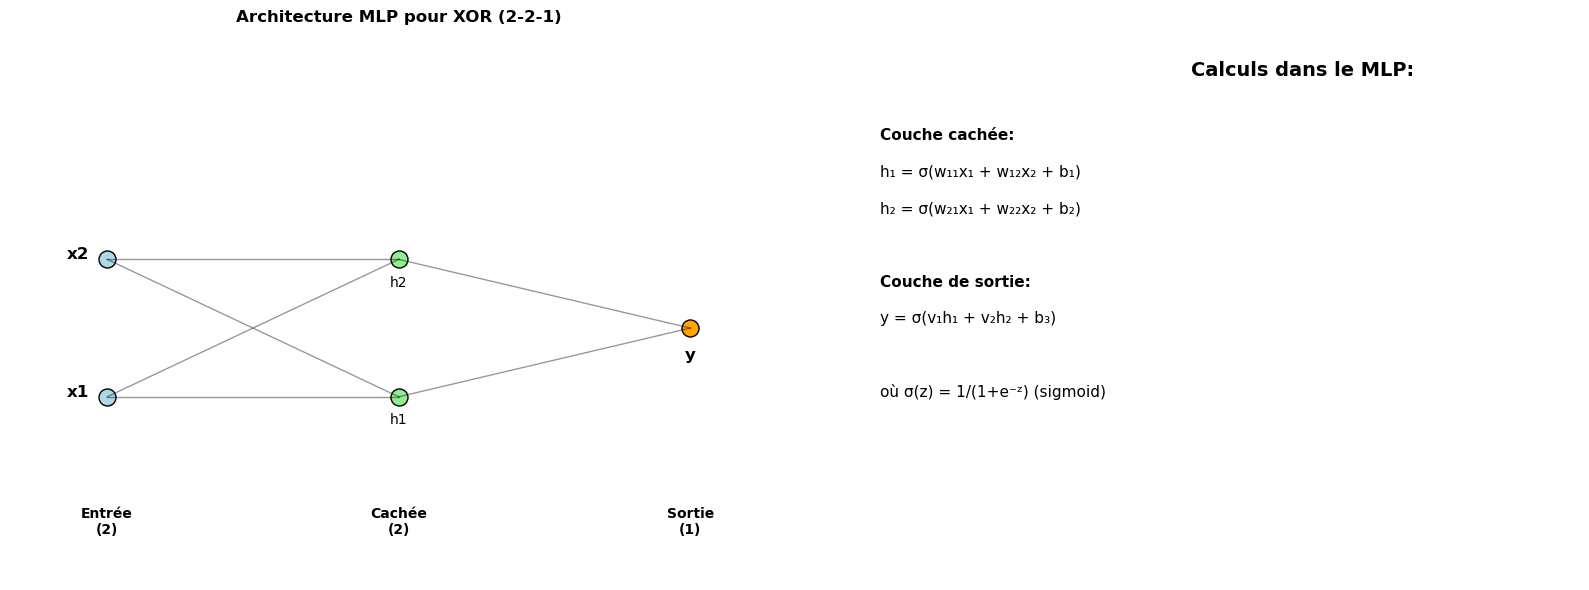

In [2]:
def visualiser_architecture_mlp():
    """Visualise l'architecture d'un MLP pour XOR"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Architecture générale
    ax1.set_xlim(0, 8)
    ax1.set_ylim(0, 6)
    
    # Couche d'entrée (2 neurones)
    for i in range(2):
        ax1.scatter(1, 2+i*1.5, s=150, c='lightblue', edgecolor='black')
        ax1.text(0.7, 2+i*1.5, f'x{i+1}', fontsize=12, ha='center', fontweight='bold')
    
    # Couche cachée (2 neurones)
    for i in range(2):
        ax1.scatter(4, 2+i*1.5, s=150, c='lightgreen', edgecolor='black')
        ax1.text(4, 1.7+i*1.5, f'h{i+1}', fontsize=10, ha='center')
        
        # Connexions entrée -> cachée
        for j in range(2):
            ax1.plot([1, 4], [2+j*1.5, 2+i*1.5], 'k-', alpha=0.4, linewidth=1)
    
    # Couche de sortie (1 neurone)
    ax1.scatter(7, 2.75, s=150, c='orange', edgecolor='black')
    ax1.text(7, 2.4, 'y', fontsize=12, ha='center', fontweight='bold')
    
    # Connexions cachée -> sortie
    for i in range(2):
        ax1.plot([4, 7], [2+i*1.5, 2.75], 'k-', alpha=0.4, linewidth=1)
    
    ax1.text(1, 0.5, 'Entrée\n(2)', ha='center', fontweight='bold')
    ax1.text(4, 0.5, 'Cachée\n(2)', ha='center', fontweight='bold')
    ax1.text(7, 0.5, 'Sortie\n(1)', ha='center', fontweight='bold')
    ax1.set_title('Architecture MLP pour XOR (2-2-1)', fontweight='bold')
    ax1.axis('off')
    
    # Calculs détaillés
    ax2.text(0.5, 5.5, 'Calculs dans le MLP:', fontsize=14, fontweight='bold')
    
    # Formules
    formules = [
        "Couche cachée:",
        "h₁ = σ(w₁₁x₁ + w₁₂x₂ + b₁)",
        "h₂ = σ(w₂₁x₁ + w₂₂x₂ + b₂)",
        "",
        "Couche de sortie:",
        "y = σ(v₁h₁ + v₂h₂ + b₃)",
        "",
        "où σ(z) = 1/(1+e⁻ᶻ) (sigmoid)"
    ]
    
    for i, formule in enumerate(formules):
        ax2.text(0.1, 4.8-i*0.4, formule, fontsize=11, 
                fontweight='bold' if formule.endswith(':') else 'normal')
    
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 6)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

visualiser_architecture_mlp()

## 🔧 2. Implémentation d'un MLP simple

Implémentons un MLP avec une couche cachée pour résoudre XOR.

In [3]:
class MLP:
    """Multi-Layer Perceptron simple"""
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # Initialisation des poids (Xavier/Glorot)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        # Historique pour visualisation
        self.losses = []
        self.accuracies = []
    
    def sigmoid(self, z):
        """Fonction d'activation sigmoid"""
        # Clip pour éviter overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_derivative(self, z):
        """Dérivée de sigmoid"""
        return z * (1 - z)
    
    def forward(self, X):
        """Propagation avant"""
        # Couche cachée
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        
        # Couche de sortie
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def backward(self, X, y, output):
        """Rétropropagation"""
        m = X.shape[0]
        
        # Erreur de sortie
        dz2 = output - y
        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        
        # Erreur couche cachée
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.sigmoid_derivative(self.a1)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        
        # Mise à jour des poids
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
    
    def train(self, X, y, epochs=1000, verbose=False):
        """Entraînement du MLP"""
        for epoch in range(epochs):
            # Propagation avant
            output = self.forward(X)
            
            # Calcul de la perte (MSE)
            loss = np.mean((output - y) ** 2)
            self.losses.append(loss)
            
            # Calcul de la précision
            predictions = (output > 0.5).astype(int)
            accuracy = np.mean(predictions == y)
            self.accuracies.append(accuracy)
            
            # Rétropropagation
            self.backward(X, y, output)
            
            if verbose and epoch % 100 == 0:
                print(f"Époque {epoch}: Loss = {loss:.4f}, Accuracy = {accuracy:.2%}")
    
    def predict(self, X):
        """Prédiction"""
        output = self.forward(X)
        return (output > 0.5).astype(int)

print("✅ Classe MLP implémentée!")

✅ Classe MLP implémentée!


## 🎯 3. Résolution du problème XOR

Testons notre MLP sur le problème XOR que le perceptron ne pouvait pas résoudre.

In [4]:
def resoudre_xor():
    """Résout le problème XOR avec un MLP"""
    
    # Données XOR
    X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([[0], [1], [1], [0]])
    
    print("🎯 Résolution du problème XOR avec MLP")
    print("="*40)
    print("Données XOR:")
    for i, (x, label) in enumerate(zip(X_xor, y_xor.flatten())):
        print(f"   {x} → {label}")
    print()
    
    # Création et entraînement du MLP
    mlp = MLP(input_size=2, hidden_size=4, output_size=1, learning_rate=1.0)
    mlp.train(X_xor, y_xor, epochs=2000, verbose=True)
    
    # Test final
    predictions = mlp.predict(X_xor)
    final_output = mlp.forward(X_xor)
    
    print("\n📊 Résultats finaux:")
    print("Input  | Target | Output | Prediction")
    print("-------|--------|--------|----------")
    for i in range(len(X_xor)):
        print(f"{X_xor[i]} |   {y_xor[i][0]}    | {final_output[i][0]:.3f}  |     {predictions[i][0]}")
    
    accuracy = np.mean(predictions == y_xor)
    print(f"\n✅ Précision finale: {accuracy:.2%}")
    
    return mlp, X_xor, y_xor

mlp_xor, X_xor, y_xor = resoudre_xor()

🎯 Résolution du problème XOR avec MLP
Données XOR:
   [0 0] → 0
   [0 1] → 1
   [1 0] → 1
   [1 1] → 0

Époque 0: Loss = 0.2589, Accuracy = 50.00%
Époque 100: Loss = 0.2052, Accuracy = 100.00%
Époque 200: Loss = 0.0289, Accuracy = 100.00%
Époque 300: Loss = 0.0048, Accuracy = 100.00%
Époque 400: Loss = 0.0017, Accuracy = 100.00%
Époque 500: Loss = 0.0008, Accuracy = 100.00%
Époque 600: Loss = 0.0005, Accuracy = 100.00%
Époque 700: Loss = 0.0003, Accuracy = 100.00%
Époque 800: Loss = 0.0002, Accuracy = 100.00%
Époque 900: Loss = 0.0002, Accuracy = 100.00%
Époque 1000: Loss = 0.0001, Accuracy = 100.00%
Époque 1100: Loss = 0.0001, Accuracy = 100.00%
Époque 1200: Loss = 0.0001, Accuracy = 100.00%
Époque 1300: Loss = 0.0001, Accuracy = 100.00%
Époque 1400: Loss = 0.0001, Accuracy = 100.00%
Époque 1500: Loss = 0.0000, Accuracy = 100.00%
Époque 1600: Loss = 0.0000, Accuracy = 100.00%
Époque 1700: Loss = 0.0000, Accuracy = 100.00%
Époque 1800: Loss = 0.0000, Accuracy = 100.00%
Époque 1900: Los

## 📊 4. Visualisation de l'apprentissage

Visualisons comment le MLP apprend à résoudre XOR.

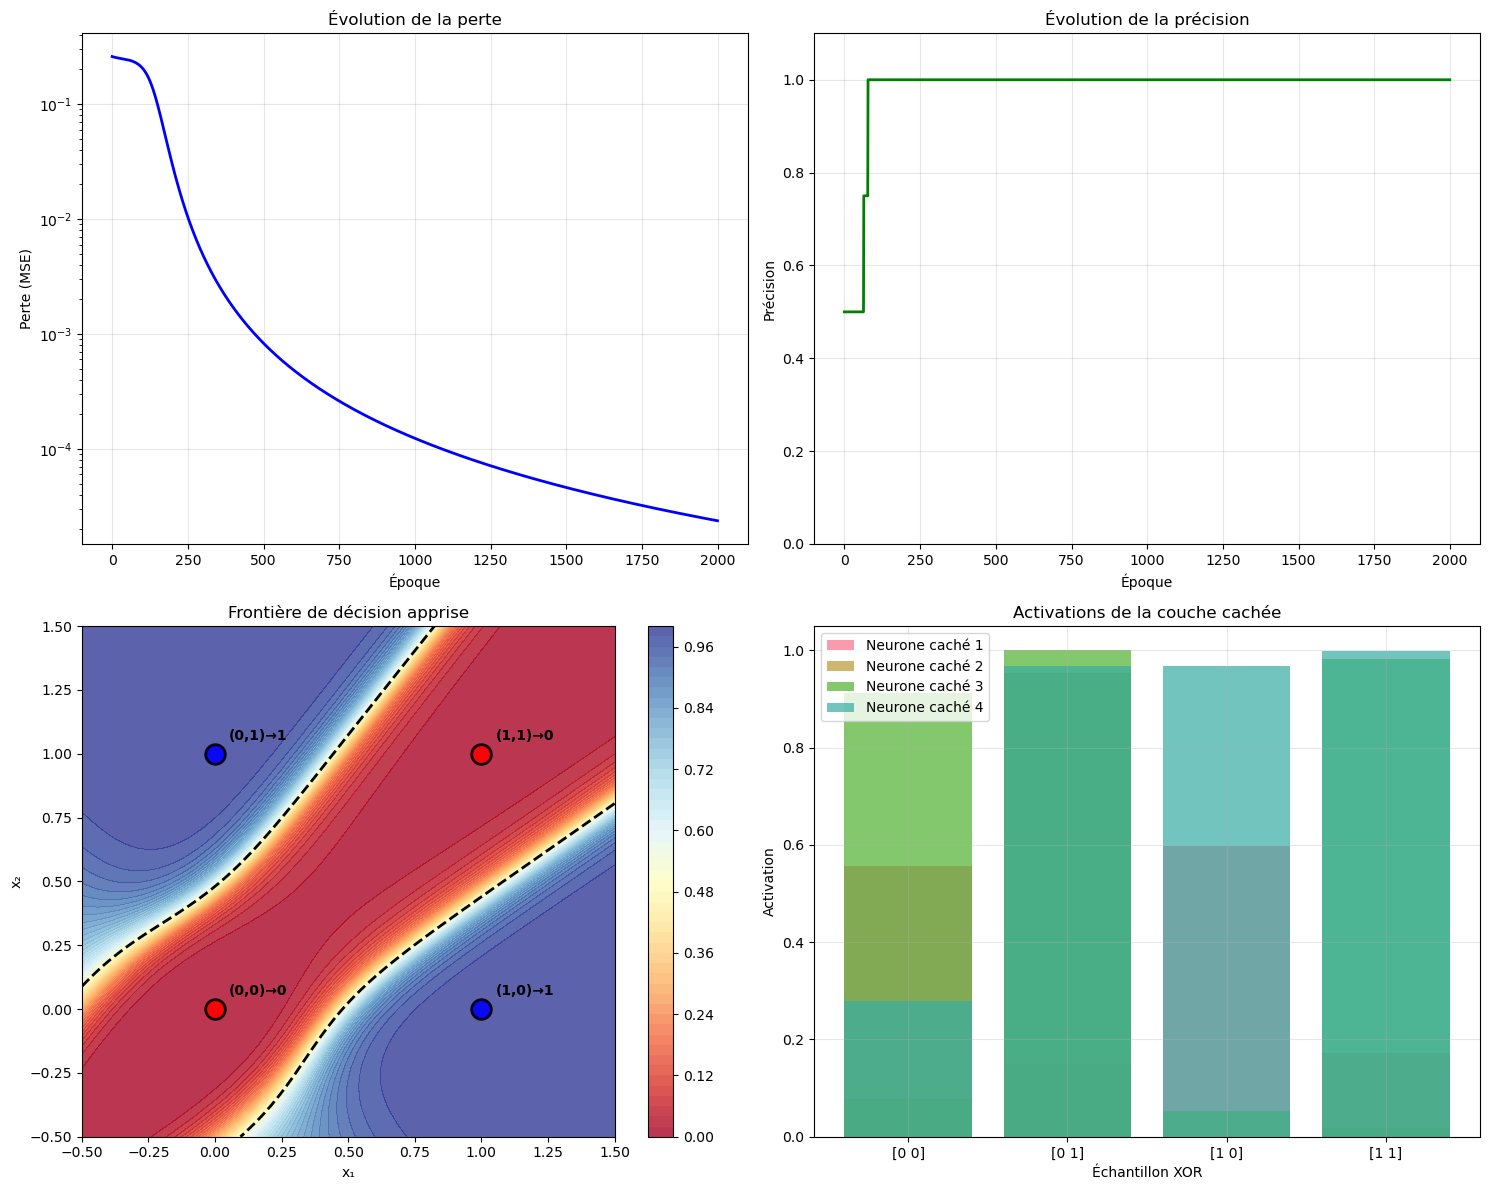

In [5]:
def visualiser_apprentissage_xor(mlp, X, y):
    """Visualise l'apprentissage du MLP sur XOR"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Évolution de la perte
    ax1 = axes[0, 0]
    ax1.plot(mlp.losses, 'b-', linewidth=2)
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Perte (MSE)')
    ax1.set_title('Évolution de la perte')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # 2. Évolution de la précision
    ax2 = axes[0, 1]
    ax2.plot(mlp.accuracies, 'g-', linewidth=2)
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Précision')
    ax2.set_title('Évolution de la précision')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.1)
    
    # 3. Frontière de décision
    ax3 = axes[1, 0]
    
    # Grille pour la frontière
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100),
                        np.linspace(-0.5, 1.5, 100))
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = mlp.forward(mesh_points)
    Z = Z.reshape(xx.shape)
    
    # Contour de décision
    contour = ax3.contourf(xx, yy, Z, levels=50, alpha=0.8, cmap='RdYlBu')
    ax3.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)
    
    # Points XOR
    colors = ['red', 'blue']
    for i in range(2):
        mask = y.flatten() == i
        ax3.scatter(X[mask, 0], X[mask, 1], 
                   c=colors[i], s=200, alpha=0.9, edgecolors='black', linewidth=2)
    
    # Annotations
    for i, (x, label) in enumerate(zip(X, y.flatten())):
        ax3.annotate(f'({x[0]},{x[1]})→{label}', 
                    (x[0], x[1]), xytext=(10, 10), 
                    textcoords='offset points', fontsize=10, fontweight='bold')
    
    ax3.set_xlabel('x₁')
    ax3.set_ylabel('x₂')
    ax3.set_title('Frontière de décision apprise')
    ax3.set_xlim(-0.5, 1.5)
    ax3.set_ylim(-0.5, 1.5)
    plt.colorbar(contour, ax=ax3)
    
    # 4. Activations de la couche cachée
    ax4 = axes[1, 1]
    
    # Calcul des activations
    hidden_activations = mlp.sigmoid(np.dot(X, mlp.W1) + mlp.b1)
    
    # Visualisation des neurones cachés
    for i in range(mlp.hidden_size):
        ax4.bar(range(len(X)), hidden_activations[:, i], 
               alpha=0.7, label=f'Neurone caché {i+1}')
    
    ax4.set_xlabel('Échantillon XOR')
    ax4.set_ylabel('Activation')
    ax4.set_title('Activations de la couche cachée')
    ax4.set_xticks(range(len(X)))
    ax4.set_xticklabels([f'{x}' for x in X])
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

visualiser_apprentissage_xor(mlp_xor, X_xor, y_xor)

## 🧮 5. Comprendre la rétropropagation

La rétropropagation calcule les gradients pour mettre à jour les poids.

In [6]:
def demo_backpropagation():
    """Démonstration détaillée de la rétropropagation"""
    
    print("🧮 DÉMONSTRATION - Rétropropagation")
    print("="*50)
    
    # Exemple simple avec un point XOR
    X_demo = np.array([[1, 0]])  # Input: (1,0)
    y_demo = np.array([[1]])     # Target: 1
    
    # MLP simple (2-2-1)
    mlp_demo = MLP(2, 2, 1, learning_rate=0.5)
    
    print("Exemple: Input (1,0) → Target 1")
    print(f"Poids initiaux W1:\n{mlp_demo.W1}")
    print(f"Poids initiaux W2:\n{mlp_demo.W2}")
    print()
    
    # Propagation avant
    print("PROPAGATION AVANT:")
    print("-" * 20)
    
    # Couche cachée
    z1 = np.dot(X_demo, mlp_demo.W1) + mlp_demo.b1
    a1 = mlp_demo.sigmoid(z1)
    print(f"Couche cachée z1 = {z1}")
    print(f"Couche cachée a1 = {a1}")
    
    # Couche de sortie
    z2 = np.dot(a1, mlp_demo.W2) + mlp_demo.b2
    a2 = mlp_demo.sigmoid(z2)
    print(f"Sortie z2 = {z2}")
    print(f"Sortie a2 = {a2}")
    print(f"Erreur = {a2[0][0] - y_demo[0][0]:.4f}")
    print()
    
    # Rétropropagation
    print("RÉTROPROPAGATION:")
    print("-" * 20)
    
    # Gradient sortie
    dz2 = a2 - y_demo
    print(f"Gradient sortie dz2 = {dz2}")
    
    # Gradients poids sortie
    dW2 = np.dot(a1.T, dz2)
    print(f"Gradient W2: dW2 = {dW2}")
    
    # Gradient couche cachée
    da1 = np.dot(dz2, mlp_demo.W2.T)
    dz1 = da1 * mlp_demo.sigmoid_derivative(a1)
    print(f"Gradient couche cachée dz1 = {dz1}")
    
    # Gradients poids cachée
    dW1 = np.dot(X_demo.T, dz1)
    print(f"Gradient W1: dW1 = {dW1}")
    print()
    
    # Mise à jour
    print("MISE À JOUR DES POIDS:")
    print("-" * 20)
    W1_new = mlp_demo.W1 - mlp_demo.learning_rate * dW1
    W2_new = mlp_demo.W2 - mlp_demo.learning_rate * dW2
    
    print(f"Nouveaux poids W1:\n{W1_new}")
    print(f"Nouveaux poids W2:\n{W2_new}")

demo_backpropagation()

🧮 DÉMONSTRATION - Rétropropagation
Exemple: Input (1,0) → Target 1
Poids initiaux W1:
[[-0.23597532  1.00416448]
 [ 0.11009256  0.26321884]]
Poids initiaux W2:
[[ 0.02679877]
 [-1.17344054]]

PROPAGATION AVANT:
--------------------
Couche cachée z1 = [[-0.23597532  1.00416448]]
Couche cachée a1 = [[0.44127841 0.73187658]]
Sortie z2 = [[-0.84698793]]
Sortie a2 = [[0.30006509]]
Erreur = -0.6999

RÉTROPROPAGATION:
--------------------
Gradient sortie dz2 = [[-0.69993491]]
Gradient W2: dW2 = [[-0.30886616]
 [-0.51226597]]
Gradient couche cachée dz1 = [[-0.00462467  0.16117265]]
Gradient W1: dW1 = [[-0.00462467  0.16117265]
 [-0.          0.        ]]

MISE À JOUR DES POIDS:
--------------------
Nouveaux poids W1:
[[-0.23366298  0.92357816]
 [ 0.11009256  0.26321884]]
Nouveaux poids W2:
[[ 0.18123185]
 [-0.91730756]]


## 🎮 6. Interface interactive pour expérimenter

Testez différentes architectures et paramètres.

In [ ]:
@interact(
    hidden_size=IntSlider(min=2, max=10, step=1, value=4, description='Neurones cachés:'),
    learning_rate=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description='Taux apprentissage:'),
    epochs=IntSlider(min=500, max=3000, step=500, value=2000, description='Époques:'),
    probleme=Dropdown(options=['XOR', 'Cercles', 'Spirale'], value='XOR', description='Problème:')
)
def mlp_interactif(hidden_size, learning_rate, epochs, probleme):
    """Interface interactive pour tester le MLP"""
    
    # Génération des données selon le problème
    if probleme == 'XOR':
        X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        y = np.array([[0], [1], [1], [0]])
        title = "Problème XOR"
    
    elif probleme == 'Cercles':
        np.random.seed(42)
        n_samples = 200
        X = np.random.randn(n_samples, 2)
        y = ((X[:, 0]**2 + X[:, 1]**2) < 1).astype(int).reshape(-1, 1)
        title = "Classification de cercles"
    
    else:  # Spirale
        np.random.seed(42)
        n_samples = 200
        t = np.linspace(0, 2*np.pi, n_samples)
        X = np.column_stack([t * np.cos(t), t * np.sin(t)]) + 0.1 * np.random.randn(n_samples, 2)
        y = (t > np.pi).astype(int).reshape(-1, 1)
        title = "Classification de spirale"
    
    # Entraînement
    mlp = MLP(input_size=2, hidden_size=hidden_size, output_size=1, learning_rate=learning_rate)
    mlp.train(X, y, epochs=epochs)
    
    # Visualisation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Frontière de décision
    if probleme == 'XOR':
        xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100),
                            np.linspace(-0.5, 1.5, 100))
    else:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                            np.linspace(y_min, y_max, 100))
    
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = mlp.forward(mesh_points)
    Z = Z.reshape(xx.shape)
    
    contour = ax1.contourf(xx, yy, Z, levels=50, alpha=0.8, cmap='RdYlBu')
    ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)
    
    # Points de données
    colors = ['red', 'blue']
    for i in range(2):
        mask = y.flatten() == i
        ax1.scatter(X[mask, 0], X[mask, 1], 
                   c=colors[i], alpha=0.7, edgecolors='black')
    
    ax1.set_title(f'{title} - Architecture: 2-{hidden_size}-1')
    ax1.set_xlabel('x₁')
    ax1.set_ylabel('x₂')
    
    # Courbes d'apprentissage
    ax2.plot(mlp.losses, 'b-', label='Perte', linewidth=2)
    ax2_twin = ax2.twinx()
    ax2_twin.plot(mlp.accuracies, 'g-', label='Précision', linewidth=2)
    
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Perte', color='blue')
    ax2_twin.set_ylabel('Précision', color='green')
    ax2.set_title('Courbes d\'apprentissage')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques finales
    predictions = mlp.predict(X)
    accuracy = np.mean(predictions == y)
    final_loss = mlp.losses[-1]
    
    print(f"📊 Résultats finaux:")
    print(f"   • Architecture: 2-{hidden_size}-1")
    print(f"   • Précision: {accuracy:.2%}")
    print(f"   • Perte finale: {final_loss:.6f}")
    print(f"   • Convergence: {'✅' if accuracy > 0.9 else '⚠️'}")

## 🎓 Résumé - MLPs et Rétropropagation

### ✅ Avantages des MLPs:
- Résolution de problèmes non-linéaires (XOR, cercles, etc.)
- Approximateur universel de fonctions
- Apprentissage automatique de représentations

### 🧮 Rétropropagation:
- Algorithme pour calculer les gradients
- Propagation de l'erreur de la sortie vers l'entrée
- Mise à jour des poids par descente de gradient

### 🚀 Prochaine étape:
**Partie 3**: Application sur un dataset réel avec optimisations avancées!

In [ ]:
def quiz_mlp():
    """Quiz sur les MLPs"""
    print("🎯 QUIZ - MLPs et Rétropropagation")
    print("="*40)
    print()
    print("1. Pourquoi un MLP peut-il résoudre XOR contrairement au perceptron?")
    print("   A) Il a plus de poids")
    print("   B) Il utilise des fonctions d'activation non-linéaires")
    print("   C) Il apprend plus vite")
    print()
    print("2. Que fait la rétropropagation?")
    print("   A) Calcule la sortie du réseau")
    print("   B) Calcule les gradients pour mettre à jour les poids")
    print("   C) Initialise les poids")
    print()
    print("3. Dans un MLP 2-4-1, combien y a-t-il de poids total?")
    print("   A) 7 (2×4 + 4×1 - 1)")
    print("   B) 12 (2×4 + 4×1)")
    print("   C) 15 (2×4 + 4×1 + 4 + 1 biais)")
    print()
    print("Réponses: 1-B, 2-B, 3-C")

quiz_mlp()